## Challenge Question and Task:

“What brain activity patterns are associated with ADHD; are they different between males and females, and, if so, how?”

The task is to create a multi-outcome model to predict two separate target variables: 1) ADHD (1=yes or 0=no) and 2) female (1=yes or 0=no).

In [6]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd

# Read the data files
train_cat = pd.read_excel('/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx')
train_FCM = pd.read_csv('/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv')
train_Quant = pd.read_excel('/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx')
train_Solutions = pd.read_excel('/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TRAIN/TRAINING_SOLUTIONS.xlsx')

In [8]:
train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1202 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1213 non-null   int64  
 5   MRI_Track_Scan_Location           1213 non-null   int64  
 6   Barratt_Barratt_P1_Edu            1213 non-null   int64  
 7   Barratt_Barratt_P1_Occ            1213 non-null   int64  
 8   Barratt_Barratt_P2_Edu            1213 non-null   int64  
 9   Barratt_Barratt_P2_Occ            1213 non-null   int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 94.9+ KB


In [12]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.2 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 29.0 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 41.8 MB/s eta 0:00:00
Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


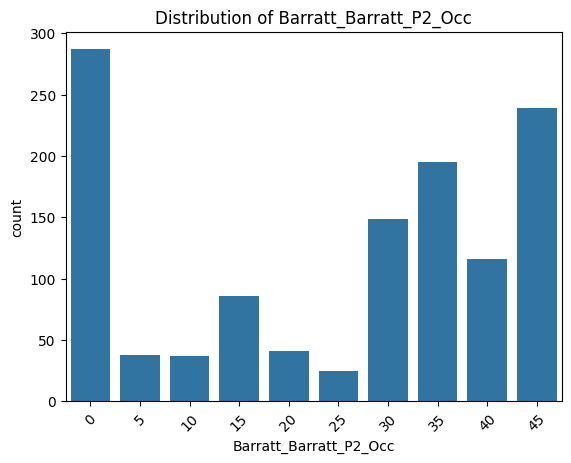

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# visualize the distribution of the categorical var 
sns.countplot(x='Barratt_Barratt_P2_Occ', data=train_cat[['Barratt_Barratt_P2_Occ']])
plt.title(f"Distribution of Barratt_Barratt_P2_Occ")
plt.xticks(rotation=45)
plt.show()

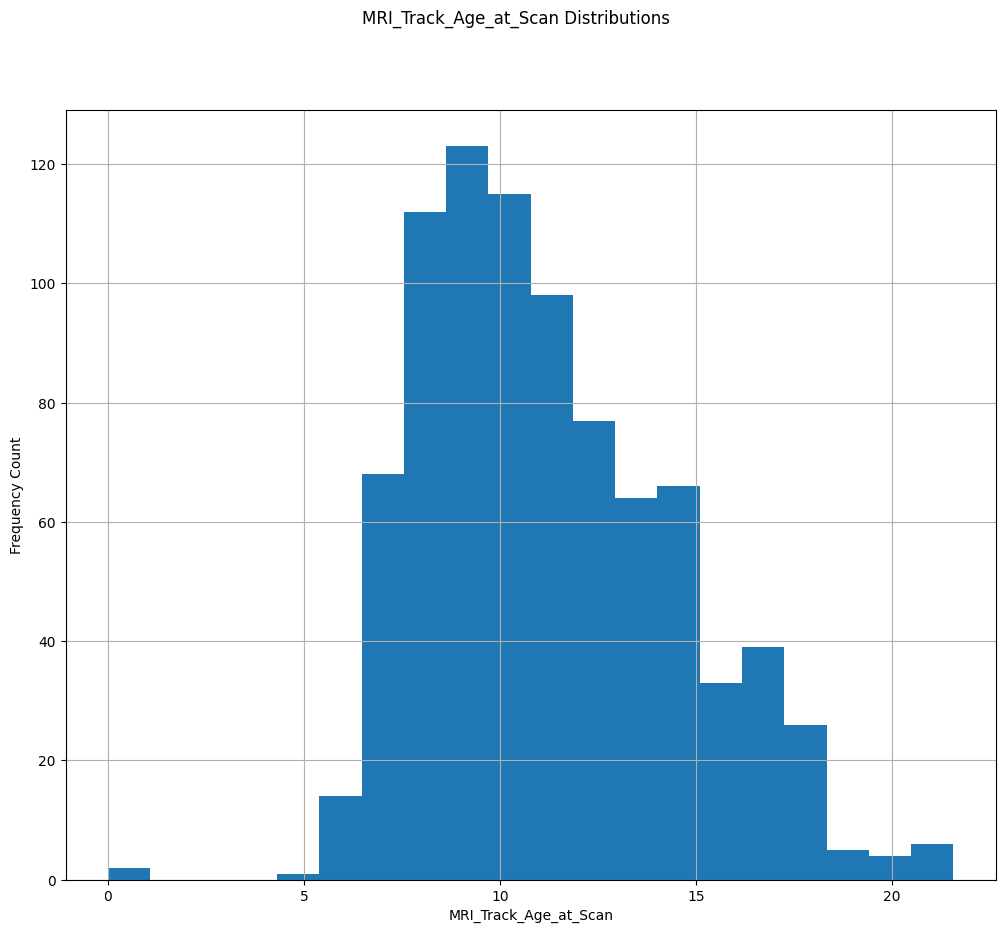

In [14]:
# visualize the distribution of the quant var
train_Quant['MRI_Track_Age_at_Scan'].hist(figsize=(12, 10), bins=20)
plt.suptitle("MRI_Track_Age_at_Scan Distributions")
plt.xlabel('MRI_Track_Age_at_Scan')
plt.ylabel('Frequency Count')
plt.show()


In [15]:
# ADHD and gender distributions
train_Solutions['ADHD_Outcome'].value_counts()
train_Solutions['Sex_F'].value_counts()


Sex_F
0    797
1    416
Name: count, dtype: int64

**Key Insight**: Gender imbalance in the dataset may introduce bias in modeling. Address this during data preparation.

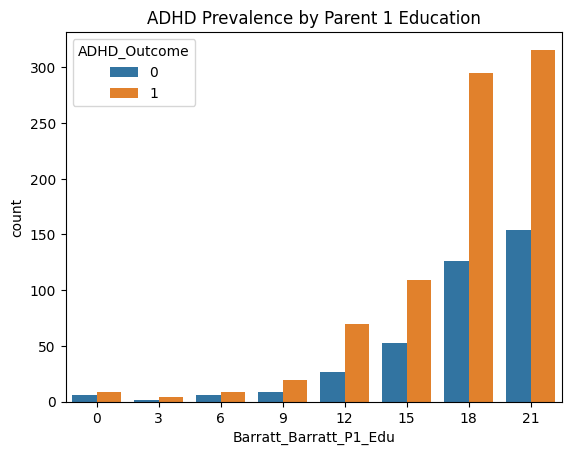

In [16]:
# look at Barratt_Barratt_P1_Edu (in train_cat) and ADHD_Outcome
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train_cat, x='Barratt_Barratt_P1_Edu', hue=train_Solutions['ADHD_Outcome'])
plt.title('ADHD Prevalence by Parent 1 Education')
plt.show()

Most of the data points fall into a specific category (e.g., 21 has 470 entries out of a total 1213). This means that even if ADHD prevalence appears higher in this category, it might just reflect that there are more people in this group overall, rather than an actual trend. 

To adress this, normalize the data or compute percentages within each category to account for differences in group sizes. Let's compute ADHD percentage for each category.

In [17]:
# Add ADHD_Outcome directly to a copy of the train_cat dataset for grouping
train_cat_copy = train_cat.copy()
train_cat_copy['ADHD_Outcome'] = train_Solutions['ADHD_Outcome']

adhd_percentages = train_cat_copy.groupby('Barratt_Barratt_P1_Edu')['ADHD_Outcome'].mean()
print(adhd_percentages)

Barratt_Barratt_P1_Edu
0     0.600000
3     0.800000
6     0.600000
9     0.678571
12    0.721649
15    0.672840
18    0.700713
21    0.672340
Name: ADHD_Outcome, dtype: float64


In [18]:
train_cat['Barratt_Barratt_P1_Edu'].value_counts()

Barratt_Barratt_P1_Edu
21    470
18    421
15    162
12     97
9      28
0      15
6      15
3       5
Name: count, dtype: int64

Smaller sample sizes can lead to greater variability and make the proportions more susceptible to outliers. This means that a few individual cases can disproportionately affect the results, making them less reliable and less representative of the broader population. Therefore, it is crucial to examine sample sizes carefully before drawing any conclusions.

## One hot encoding on categorical variables
Avoid Implying Ordinal Relationships


1.  If you encode categories using numbers directly (e.g., 0, 1, 2), the algorithm might interpret these numbers as having a meaningful order or scale, which could lead to incorrect assumptions.
2.  One-hot encoding eliminates this problem by assigning each category its own binary column, ensuring no ordinal relationship is implied.


Improve Algorithm Performance


*  Algorithms like logistic regression, decision trees, and neural networks often perform better with one-hot encoded data because it provides clear distinctions between categories.
*  Without one-hot encoding, algorithms might struggle to learn from categorical variables or produce biased results.

In [19]:
# convert integer columns in a DataFrame to categorical data type
for col in train_cat.select_dtypes(include='int').columns:
    train_cat[col] = train_cat[col].astype('category')

In [20]:
# create a list of all the columns except the first one participant id and label those columns_to_encode
columns_to_encode = train_cat.columns[1:].tolist()

# Print the columns to encode
print("Columns to encode:", columns_to_encode)

Columns to encode: ['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [22]:
# encoding categorical data
train_encoded = pd.get_dummies(train_cat[columns_to_encode], drop_first=True) #the drop_first=True parameter avoids the "dummy variable trap" by dropping the first category for each feature,reducing redundancy in the encoded data.
train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

#reintroducing partcipant id after encoding
cat_train_final = pd.concat([train_cat.drop(columns=columns_to_encode), train_encoded], axis=1)

# ensure it looks correct
cat_train_final.head()

/var/folders/d6/4p_1xcns3_qf115v1h9bqk700000gn/T/ipykernel_78788/2836270031.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


,participant_id,PreInt_Demos_Fam_Child_Ethnicity,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,...,Barratt_Barratt_P2_Edu_21,Barratt_Barratt_P2_Occ_5,Barratt_Barratt_P2_Occ_10,Barratt_Barratt_P2_Occ_15,Barratt_Barratt_P2_Occ_20,Barratt_Barratt_P2_Occ_25,Barratt_Barratt_P2_Occ_30,Barratt_Barratt_P2_Occ_35,Barratt_Barratt_P2_Occ_40,Barratt_Barratt_P2_Occ_45
0,UmrK0vMLopoR,0.0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,CPaeQkhcjg7d,1.0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nb4EetVPm3gs,1.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,p4vPhVu91o4b,0.0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,M09PXs7arQ5E,0.0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


## Train and test dataframes

Now we need to apply the same encoding steps to the categorical dataframe in the testing data. It's essential to ensure that any preprocessing done on the training data is also applied to the test data to ensure accurate model predictions.

In [23]:
test_cat = pd.read_excel('/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx')
# convert our int variables to categories
for col in test_cat.select_dtypes(include='int').columns:
    test_cat[col] = test_cat[col].astype('category')

# Encode categorical variables in test
test_encoded = pd.get_dummies(test_cat[columns_to_encode], drop_first=True)
test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Ensure test_encoded has the same columns as train_encoded
missing_cols = set(train_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0  # Add missing columns with 0 values

# Ensure test_encoded columns are in the same order as train_encoded
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# Combine encoded columns with the rest of the DataFrame
cat_test_final = pd.concat([test_cat.drop(columns=columns_to_encode), test_encoded], axis=1)

cat_test_final.head()

/var/folders/d6/4p_1xcns3_qf115v1h9bqk700000gn/T/ipykernel_78788/683637356.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


,participant_id,PreInt_Demos_Fam_Child_Ethnicity,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,...,Barratt_Barratt_P2_Edu_21,Barratt_Barratt_P2_Occ_5,Barratt_Barratt_P2_Occ_10,Barratt_Barratt_P2_Occ_15,Barratt_Barratt_P2_Occ_20,Barratt_Barratt_P2_Occ_25,Barratt_Barratt_P2_Occ_30,Barratt_Barratt_P2_Occ_35,Barratt_Barratt_P2_Occ_40,Barratt_Barratt_P2_Occ_45
0,Cfwaf5FX7jWK,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,vhGrzmvA3Hjq,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ULliyEXjy4OV,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LZfeAb1xMtql,0.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,EnFOUv0YK1RG,2.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Merging data frames

All the dataframes include a participant_id variable, which serves as the unique identifier for each patient. The result of merging will be two final dataframes, train df and test df. 

In [24]:
# merge training data
train_cat_FCM = pd.merge(cat_train_final, train_FCM, on = 'participant_id')
train_df = pd.merge(train_cat_FCM, train_Quant, on = 'participant_id')

# ensure it looks accurate
train_df.head()

# merge test data
file_path_testFCM = "/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TEST/TEST_FCM.csv"
test_FCM = pd.read_csv(file_path_testFCM)
#print(train_FCM.head())

file_path_testQ = "/Users/yingzhaozhou/Desktop/wids-2025-h-y/widsdatathon2025/TEST/TEST_QUANTITATIVE.xlsx"
test_Quant = pd.read_excel(file_path_testQ)
#print(train_Quant.head())

test_cat_FCM = pd.merge(cat_test_final, test_FCM, on = 'participant_id')

test_df = pd.merge(test_cat_FCM, test_Quant, on = 'participant_id')

# ensure it looks accurate
test_df.head()


,participant_id,PreInt_Demos_Fam_Child_Ethnicity,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,Cfwaf5FX7jWK,0.0,0,0,0,0,0,0,0,0,...,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,vhGrzmvA3Hjq,0.0,0,0,0,0,0,0,0,0,...,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,ULliyEXjy4OV,0.0,0,0,0,0,0,0,0,0,...,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,LZfeAb1xMtql,0.0,0,0,0,0,0,0,0,0,...,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,EnFOUv0YK1RG,2.0,0,0,0,0,0,0,0,0,...,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350


## Imputation
first using a midrange approach by filling the missing values using the mean of each column if its numerical, or Mode if categorical. 

In [38]:
# check how many NA values we have
print(train_df.isna().sum())

# 371 NANs values
# 360 in MRI_Track_age_at_Scan
# 11 in PreInt_Demos_Fam_Child_Ethnicity

train_df.fillna({'MRI_Track_Age_at_Scan':train_df['MRI_Track_Age_at_Scan'].mean()}, inplace = True)
train_df['PreInt_Demos_Fam_Child_Ethnicity'].ffill(inplace=True)

# fill categorical variable using mode
train_df['PreInt_Demos_Fam_Child_Ethnicity'].fillna(train_df['PreInt_Demos_Fam_Child_Ethnicity'].mode()[0], inplace=True)

print(train_df.isna().sum().sum()) # should now be zero

participant_id                      0
PreInt_Demos_Fam_Child_Ethnicity    0
Basic_Demos_Enroll_Year_2016        0
Basic_Demos_Enroll_Year_2017        0
Basic_Demos_Enroll_Year_2018        0
                                   ..
SDQ_SDQ_Hyperactivity               0
SDQ_SDQ_Internalizing               0
SDQ_SDQ_Peer_Problems               0
SDQ_SDQ_Prosocial                   0
MRI_Track_Age_at_Scan               0
Length: 19973, dtype: int64
0


/var/folders/d6/4p_1xcns3_qf115v1h9bqk700000gn/T/ipykernel_78788/1649742728.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['PreInt_Demos_Fam_Child_Ethnicity'].ffill(inplace=True)
/var/folders/d6/4p_1xcns3_qf115v1h9bqk700000gn/T/ipykernel_78788/1649742728.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [39]:
# Fill NAs of test data

for col in test_df.columns:
    if test_df[col].isna().sum() > 0:  # Check if the column has NaN values
        if test_df[col].dtype in ['float64', 'int64']:  # Ensure it's numeric
            test_df[col] = test_df[col].fillna(test_df[col].mean())  # Avoid inplace
        else:
            print(f"Skipping non-numeric column: {col}")

## Performing ML
Since this challenge is trying to answer the question:

What brain activity patterns are associated with ADHD; are they different between males and females, and, if so, how?

Our predictions or target variables in this model are gender (1 = female, 0 = male) and ADHD diagnosis (1 = has ADHD, 0 = does not). Both are classification problems, meaning the outputs are binary: each prediction will either be 0 or 1, representing a boolean result.

To predict both target variables simultaneously, we will use a multi-outcome machine learning model. Research suggests that women with ADHD are often underdiagnosed, and by modeling gender and ADHD diagnosis together, we can explore potential relationships between these variables. Using the same feature variables to predict both targets allows us to examine this connection in a systematic way. A multi-outcome model is ideal for this purpose because it efficiently handles the simultaneous prediction of both variables while leveraging any potential interdependencies between them.

Additionally, using a multi-outcome model streamlines the workflow. We only need to preprocess the data once, and we can train a single model instead of separate models for each target. This not only saves time and computational resources but also simplifies the overall process, making it easier to maintain consistency across predictions for gender and ADHD diagnosis.

In [27]:
X_train = train_df.drop(columns=['participant_id'])
Y_train = train_Solutions.drop(columns=['participant_id'])

## XGBoost
Key Parameters Explained:

*  objective='binary:logistic': Specifies the task type as binary classification, with logistic regression as the objective function.
*  n_estimators=100: Sets the number of boosting rounds (i.e., the number of trees to train in the ensemble).
*  learning_rate=0.1: Determines the step size shrinkage used to prevent overfitting. Lower values result in slower learning but can improve accuracy.
*  max_depth=5: Limits the depth of each decision tree to prevent overfitting while ensuring the model captures enough complexity.

In [28]:
pip install xgboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

# Initialize the base classifier
xgb_classifier = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=5)

# Wrap with MultiOutputClassifier for multi-target classification
multioutput_classifier = MultiOutputClassifier(xgb_classifier)

# train the model
multioutput_classifier.fit(X_train, Y_train)

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...))

## Testing the model

In [31]:
participant_id = test_df['participant_id']
X_test = test_df.drop(columns = 'participant_id')
y_pred = multioutput_classifier.predict(X_test)

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(
    y_pred,
    columns=['Predicted_Gender', 'Predicted_ADHD']
)

# Combine participant IDs with predictions
result_df = pd.concat([participant_id.reset_index(drop=True), predictions_df], axis=1)

# Print or save the DataFrame
print(result_df)

    participant_id  Predicted_Gender  Predicted_ADHD
0     Cfwaf5FX7jWK                 1               0
1     vhGrzmvA3Hjq                 1               0
2     ULliyEXjy4OV                 1               0
3     LZfeAb1xMtql                 0               0
4     EnFOUv0YK1RG                 1               0
..             ...               ...             ...
299   UadZfjdEg7eG                 1               0
300   IUEHiLmQAqCi                 1               0
301   cRySmCadYFRO                 1               1
302   E3MvDUtJadc5                 1               0
303   dQJXfyRazknD                 1               0

[304 rows x 3 columns]


## Evaluating ML model - Cross validation score


In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

# define a custom accuracy metric
def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])

# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy)

# Perform cross-validation on the training data
cv_scores = cross_val_score(multioutput_classifier, X_train, Y_train, cv=5, scoring=multi_output_scorer)

# Output the cross-validation results
print("Cross-validation scores for each fold:", cv_scores)
print("Mean CV score:", np.mean(cv_scores))

Cross-validation scores for each fold: [0.82716049 0.78600823 0.7037037  0.65495868 0.32438017]
Mean CV score: 0.6592422541917491


Notably, this CV score is not optimal, our model is not going to be extremely accurate without feature selection and engineering.

## Logistic Regression for Feature selection

52throw_53thcolumn           0.446963
50throw_53thcolumn           0.443249
121throw_147thcolumn         0.429988
101throw_131thcolumn         0.427367
164throw_189thcolumn         0.426777
114throw_121thcolumn         0.423242
53throw_55thcolumn           0.422395
Barratt_Barratt_P1_Edu_9     0.409823
160throw_190thcolumn         0.403888
MRI_Track_Scan_Location_4    0.398209
dtype: float64


/opt/anaconda3/envs/wids-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


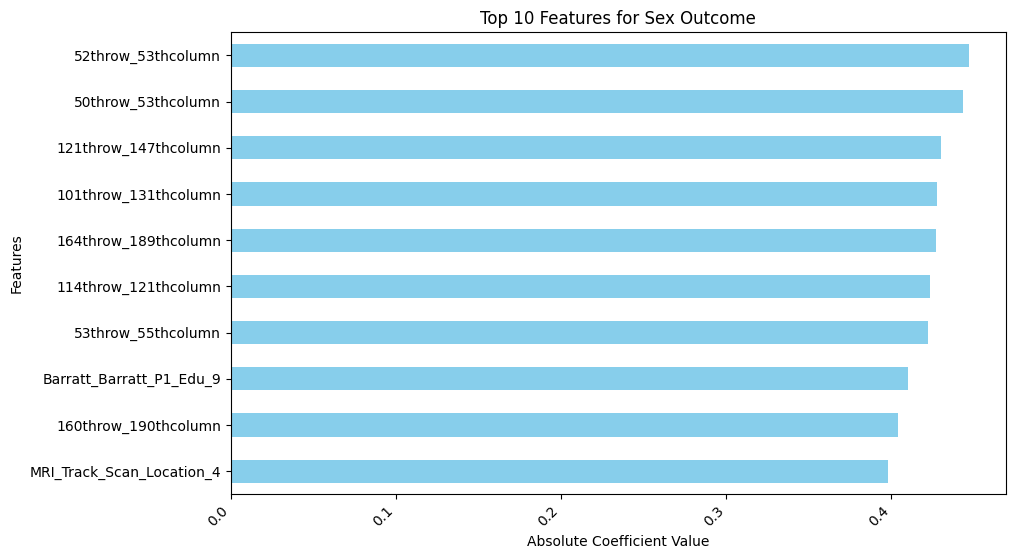

Basic_Demos_Enroll_Year_2016     0.811084
Barratt_Barratt_P1_Occ_25        0.524751
SDQ_SDQ_Hyperactivity            0.481284
Basic_Demos_Enroll_Year_2018     0.476129
Basic_Demos_Enroll_Year_2017     0.442949
MRI_Track_Scan_Location_3        0.430938
Barratt_Barratt_P1_Occ_35        0.420209
8throw_96thcolumn                0.414204
MRI_Track_Scan_Location_1        0.393515
PreInt_Demos_Fam_Child_Race_8    0.392937
dtype: float64


/opt/anaconda3/envs/wids-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


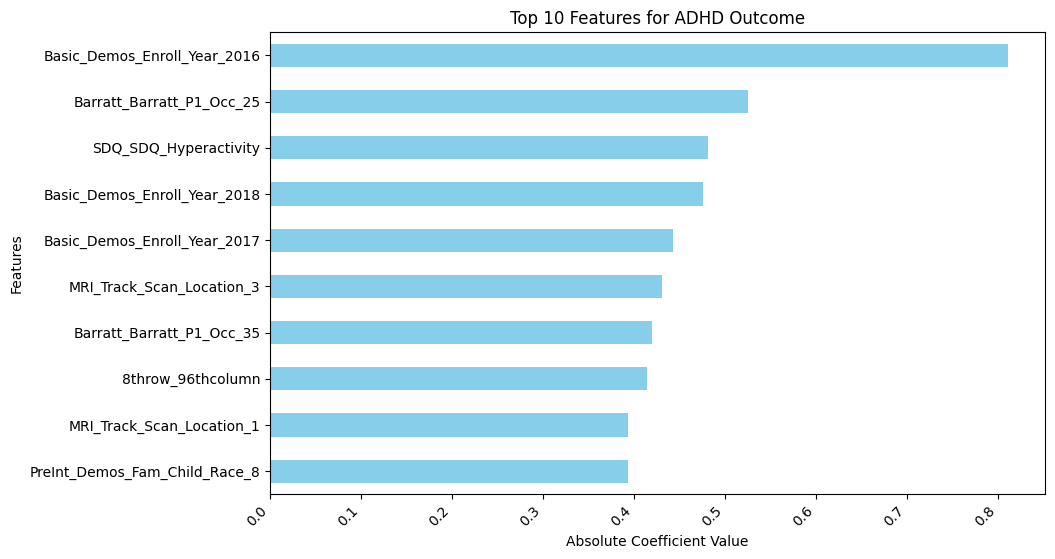

Index(['PreInt_Demos_Fam_Child_Ethnicity', 'Basic_Demos_Enroll_Year_2017',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Race_1',
       'PreInt_Demos_Fam_Child_Race_2', 'PreInt_Demos_Fam_Child_Race_9',
       'MRI_Track_Scan_Location_1', 'MRI_Track_Scan_Location_3',
       ...
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Prosocial', 'MRI_Track_Age_at_Scan'],
      dtype='object', length=412)
Index(['PreInt_Demos_Fam_Child_Ethnicity', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Race_1',
       'PreInt_Demos_Fam_Child_Race_2', 'PreInt_Demos_Fam_Child_Race_8',
       'MRI_Track_Scan_Location_1', 'MRI_Track_Scan_Location

In [35]:
from sklearn.linear_model import LogisticRegression

# check feature importance with Sex as a target
model = LogisticRegression(max_iter=1000)
model.fit(train_df.drop(columns='participant_id'), train_Solutions['Sex_F'])

# Get coefficients for Sex prediction
coefficients = pd.Series(model.coef_[0], index=train_df.drop(columns='participant_id').columns)

# Select top features for Sex prediction
top_features = coefficients.abs().nlargest(10)
print(top_features)

#Plotting the top 10 coefficents for Sex Outcome
plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Features for Sex Outcome')
plt.ylabel('Features')
plt.xlabel('Absolute Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.show()

# check feature importance with ADHD as a target
model = LogisticRegression(max_iter=1000)
model.fit(train_df.drop(columns='participant_id'), train_Solutions['ADHD_Outcome'])

# Get coefficients for ADHD_Outcome prediction
coefficients = pd.Series(model.coef_[0], index=train_df.drop(columns='participant_id').columns)

# Select top features for ADHD_Outcome prediction
top_features = coefficients.abs().nlargest(10)
print(top_features)

#Plotting the top 10 coefficents
plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Features for ADHD Outcome')
plt.ylabel('Features')
plt.xlabel('Absolute Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.show()

# use L1 regularization with Sex as a target
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(train_df.drop(columns='participant_id'), train_Solutions['Sex_F'])

selected_features_Sex = train_df.drop(columns='participant_id').columns[model.coef_[0] != 0]
print(selected_features_Sex)

# use L1 regularization with ADHD as a target
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(train_df.drop(columns='participant_id'), train_Solutions['ADHD_Outcome'])

selected_features_ADHD = train_df.drop(columns='participant_id').columns[model.coef_[0] != 0]
print(selected_features_ADHD)

## Row selection and reduction to improve the model

In [36]:
# Step 1: Find common features between ADHD and Sex selected features
common_features = list(set(selected_features_ADHD) & set(selected_features_Sex))

X_train_2 = X_train[common_features]
X_test_2 = X_test[common_features]

# Step 2: Train and test the model
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

# Initialize the base classifier
xgb_classifier = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=5)

# Wrap with MultiOutputClassifier for multi-target classification
multioutput_classifier = MultiOutputClassifier(xgb_classifier)

# Train the model
multioutput_classifier.fit(X_train_2, Y_train)

y_pred_2 = multioutput_classifier.predict(X_test_2)

# Convert predictions to a DataFrame
predictions_df_2 = pd.DataFrame(
    y_pred_2,
    columns=['Predicted_Gender', 'Predicted_ADHD']
)

# Combine participant IDs with predictions
result_df_2 = pd.concat([participant_id.reset_index(drop=True), predictions_df_2], axis=1)
result_df_2.head()

# Evaluate the model with cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy)

# Perform cross-validation on the training data
cv_scores_2 = cross_val_score(multioutput_classifier, X_train_2, Y_train, cv=5, scoring=multi_output_scorer, n_jobs=-1)

# Output the cross-validation results
print("Cross-validation scores for each fold:", cv_scores_2)
print("Mean CV score:", np.mean(cv_scores_2))


Cross-validation scores for each fold: [0.77572016 0.77160494 0.69341564 0.66115702 0.4338843 ]
Mean CV score: 0.6671564126109581


## SVM

In [40]:
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the base SVM classifier
svm_classifier = SVC(kernel='rbf', probability=True)

# Wrap with MultiOutputClassifier for multi-target classification
multioutput_svm = MultiOutputClassifier(svm_classifier)

# Train the model using the reduced feature set (X_train_2)
multioutput_svm.fit(X_train_2, Y_train)

# Make predictions on test set
svm_pred = multioutput_svm.predict(X_test_2)

# Convert predictions to a DataFrame
svm_predictions_df = pd.DataFrame(
    svm_pred,
    columns=['Predicted_Gender', 'Predicted_ADHD']
)

# Combine participant IDs with predictions
svm_result_df = pd.concat([participant_id.reset_index(drop=True), svm_predictions_df], axis=1)

# Evaluate using cross-validation
cv_scores_svm = cross_val_score(multioutput_svm, X_train_2, Y_train, cv=5, scoring=multi_output_scorer, n_jobs=-1)

# Output the cross-validation results
print("SVM Cross-validation scores for each fold:", cv_scores_svm)
print("SVM Mean CV score:", np.mean(cv_scores_svm))

SVM Cross-validation scores for each fold: [0.83127572 0.80658436 0.70987654 0.55785124 0.26859504]
SVM Mean CV score: 0.6348365813012278


## Random Forests

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the base Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Wrap with MultiOutputClassifier for multi-target classification
multioutput_rf = MultiOutputClassifier(rf_classifier)

# Train the model using the reduced feature set (X_train_2)
multioutput_rf.fit(X_train_2, Y_train)

# Make predictions on test set
rf_pred = multioutput_rf.predict(X_test_2)

# Convert predictions to a DataFrame
rf_predictions_df = pd.DataFrame(
    rf_pred,
    columns=['Predicted_Gender', 'Predicted_ADHD']
)

# Combine participant IDs with predictions
rf_result_df = pd.concat([participant_id.reset_index(drop=True), rf_predictions_df], axis=1)

# Evaluate using cross-validation
cv_scores_rf = cross_val_score(multioutput_rf, X_train_2, Y_train, cv=5, scoring=multi_output_scorer, n_jobs=-1)

# Output the cross-validation results
print("Random Forest Cross-validation scores for each fold:", cv_scores_rf)
print("Random Forest Mean CV score:", np.mean(cv_scores_rf))

Random Forest Cross-validation scores for each fold: [0.82304527 0.80452675 0.72016461 0.65289256 0.37190083]
Random Forest Mean CV score: 0.674506002788831


## Neural Networks

In [45]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2)
X_test_scaled = scaler.transform(X_test_2)

# Build the neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_2.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activatio
    n='relu'),
    Dense(2, activation='sigmoid')  # 2 outputs for gender and ADHD
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, Y_train, 
                   epochs=50,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)

# Make predictions
nn_pred = model.predict(X_test_scaled)
nn_pred = (nn_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

# Create predictions DataFrame
nn_predictions_df = pd.DataFrame(
    nn_pred,
    columns=['Predicted_Gender', 'Predicted_ADHD']
)

# Combine participant IDs with predictions
nn_result_df = pd.concat([participant_id.reset_index(drop=True), nn_predictions_df], axis=1)

# Print sample of results
print(nn_result_df.head())

Epoch 1/50


/opt/anaconda3/envs/wids-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6324 - loss: 0.6771 - val_accuracy: 0.5350 - val_loss: 1.0133
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9420 - loss: 0.5294 - val_accuracy: 0.5350 - val_loss: 1.2038
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9502 - loss: 0.5055 - val_accuracy: 0.5350 - val_loss: 1.1522
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.4915 - val_accuracy: 0.5350 - val_loss: 1.1398
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9477 - loss: 0.4943 - val_accuracy: 0.5350 - val_loss: 1.1391
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9505 - loss: 0.4665 - val_accuracy: 0.5350 - val_loss: 1.1161
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9377 - loss: 0.4687 - val_accuracy: 0.5350 - val_loss: 1.1384
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9513 - loss: 0.4443 - val_accuracy: 0.5473 - val_loss: 1.1165
Epo

Training accuracy improves a lot — from ~60% to over 90%. Validation accuracy improves slightly, hovering between 53%–60%. Validation loss is not decreasing consistently — it fluctuates and even increases toward the end. This looks like overfitting. 

It looks like random forests is the best model by comparing accuracy. To improve interpretability, we can use SHAP values to understand how model features impact predictions.

In [52]:
%pip install shap

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.44.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (4.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.5/546.5 kB 12.7 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 39.5 MB/s eta 0:00:00
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.1-py3-none-any.whl (20 kB)
Using cached llvmlite-0.44.0-cp310-cp310-macosx_11_0_arm64.whl (26.2 MB)
Note: you may need to restart the kernel to use updated packages.


<Figure size 640x480 with 0 Axes>

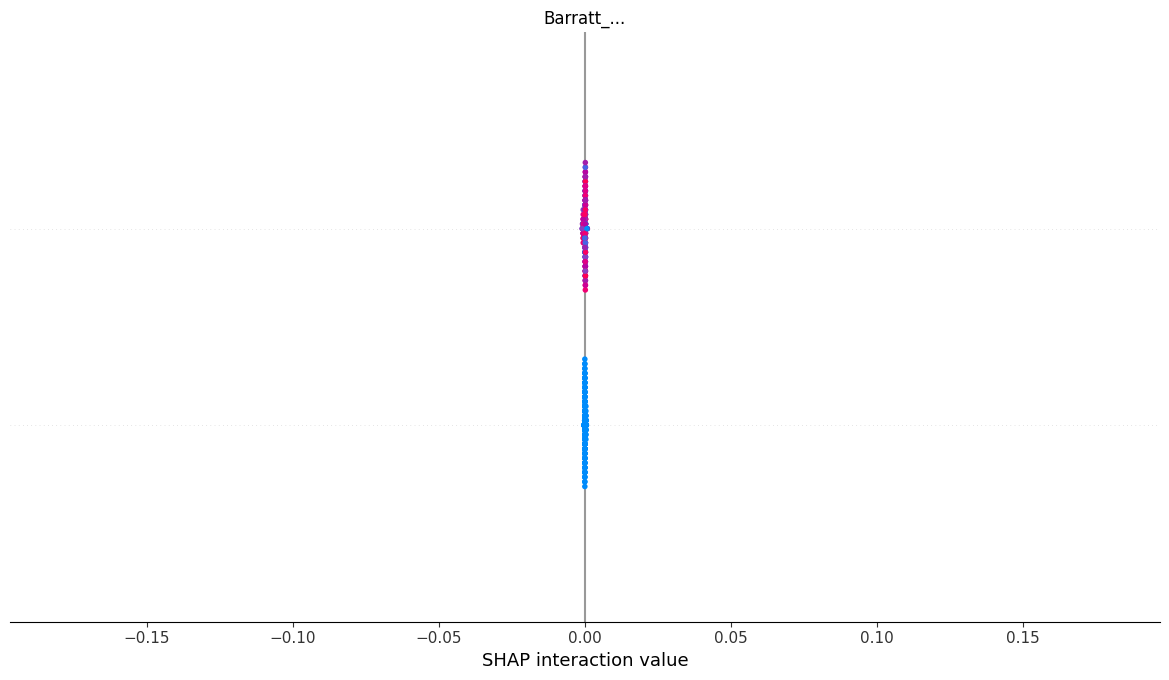

<Figure size 640x480 with 0 Axes>

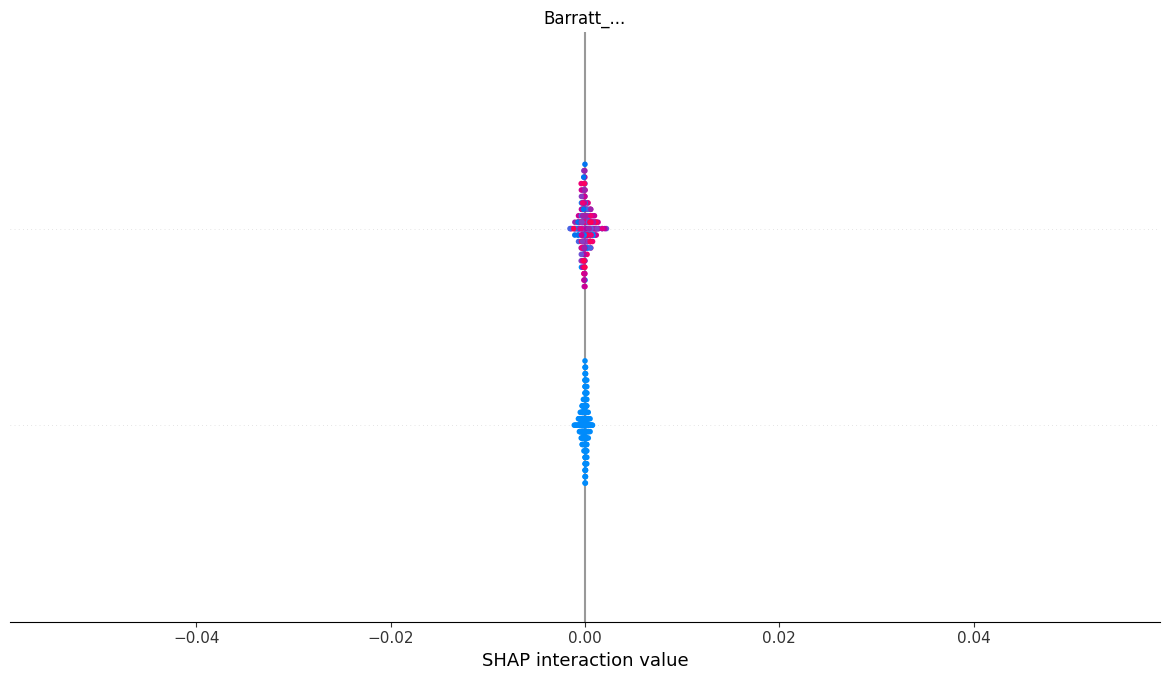

Text(0.5, 1.0, 'Top Features Impacting ADHD Classification (SHAP Values)')

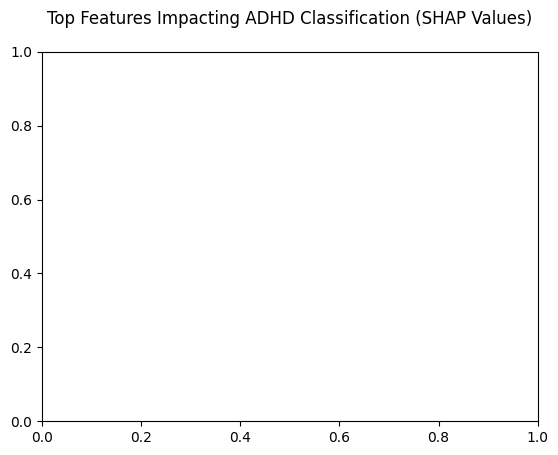

In [75]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import shap

# Create SHAP explainer for each target separately
# For gender prediction (first estimator)
explainer_gender = shap.TreeExplainer(multioutput_rf.estimators_[0])
shap_values_gender = explainer_gender.shap_values(X_test_2)

# For ADHD prediction (second estimator)
explainer_adhd = shap.TreeExplainer(multioutput_rf.estimators_[1])
shap_values_adhd = explainer_adhd.shap_values(X_test_2)

# Create SHAP summary plots with readable feature names
# For gender prediction
# Create mapping for more descriptive feature names
shap.summary_plot(
    shap_values_gender, 
    X_test_2)
plt.title("Top Features Impacting Gender Classification (SHAP Values)", pad=20)

# For ADHD prediction 
shap.summary_plot(
    shap_values_adhd, 
    X_test_2)
plt.title("Top Features Impacting ADHD Classification (SHAP Values)", pad=20)
